In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import scvi
import matplotlib as mpl
import torch
import os
import os.path
from IPython.display import display

import scipy
from sklearn.neighbors import NearestNeighbors

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set parameters

In [2]:
neighbors = 15
nPCs = 30
leiden_resolution = 1
min_distUMAP = 0.2
n_neighbors = 15

In [3]:
scvi.settings.seed = 0
batch_size = 1024
max_epochs = 1000
earlyStopping = True
learning_rate = 0.0005
scvi_layers = 4
scvi_latent = 30

torch.set_float32_matmul_precision('high')

SCVI_LATENT_KEY = "X_scvi"
SCVI_CLUSTERS_KEY = "clusters_scvi"
SCANVI_LATENT_KEY = "X_scANVI"


neighbors = 15
percentile_threshold = 80

Seed set to 0


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1614: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/Context.cpp:45.)
  _C._set_float32_matmul_precision(precision)


In [4]:
input_file="/vast/projects/chenyuli/nephrobase/levinsj/adata/fetal_annotated_AllCells_withXenium_preSCANVI_part2.h5ad"
output_file="/vast/projects/chenyuli/nephrobase/levinsj/adata/fetal_annotated_AllCells_withXenium_postSCANVI_pre_anno.h5ad"

scVI_model_update = "/vast/projects/chenyuli/nephrobase/levinsj/scvi_models/fetal_xenium_cosmx_V4/"


In [5]:
adata = sc.read_h5ad(input_file)
model = scvi.model.SCVI.load(scVI_model_update, adata=adata)
print(adata)

INFO     File /vast/projects/chenyuli/nephrobase/levinsj/scvi_models/fetal_xenium_cosmx_V4/model.pt already        
         downloaded                                                                                                


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 710417 × 659
    obs: 'sample', 'type', 'tech', 'pct_counts_mt', 'total_counts', 'nCount_RNA', 'n_genes_by_counts', 'n_counts', '_scvi_batch', '_scvi_labels', 'cellType_SCANVI', 'mean_distance'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cellType_SCANVI_colors', 'neighbors', 'sample_colors', 'tech_colors', 'type_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'All_counts', 'counts', 'log1p'
    obsp: 'connectivities', 'distances'


In [6]:
adata.obs["cellType_SCANVI"] = adata.obs["cellType_SCANVI"].astype(str).str.strip().astype("category")

scanvi_model = scvi.model.SCANVI.from_scvi_model(
    model,
    adata=adata,
    labels_key="cellType_SCANVI",
    unlabeled_category="NA",
)

INFO     Training for 5 epochs.                                                                                    


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Epoch 5/5:  80%|████████  | 4/5 [00:50<00:12, 12.34s/it, v_num=1, train_loss=176]

Epoch 5/5: 100%|██████████| 5/5 [01:02<00:00, 12.21s/it, v_num=1, train_loss=176]

Epoch 5/5: 100%|██████████| 5/5 [01:02<00:00, 12.21s/it, v_num=1, train_loss=175]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 5/5: 100%|██████████| 5/5 [01:02<00:00, 12.52s/it, v_num=1, train_loss=175]

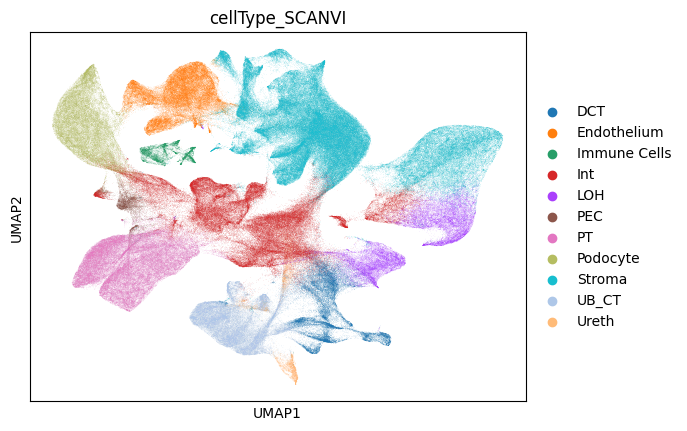

In [7]:
scanvi_model.train(max_epochs = 5, plan_kwargs={"lr":learning_rate}, early_stopping = earlyStopping, batch_size=batch_size)
latent = scanvi_model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=min_distUMAP)
sc.pl.umap(adata, color = "cellType_SCANVI")

INFO     Training for 5 epochs.                                                                                    


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Epoch 5/5:  80%|████████  | 4/5 [00:54<00:13, 13.58s/it, v_num=1, train_loss=148]

Epoch 5/5: 100%|██████████| 5/5 [01:07<00:00, 13.55s/it, v_num=1, train_loss=148]

Epoch 5/5: 100%|██████████| 5/5 [01:07<00:00, 13.55s/it, v_num=1, train_loss=145]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 5/5: 100%|██████████| 5/5 [01:07<00:00, 13.54s/it, v_num=1, train_loss=145]

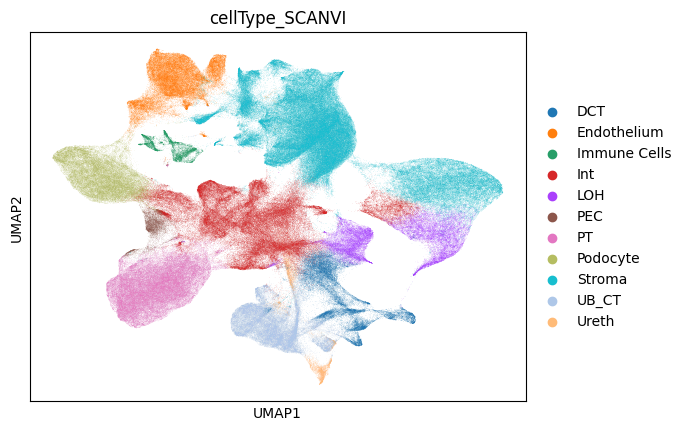

In [8]:
scanvi_model.train(max_epochs = 5, plan_kwargs={"lr":learning_rate}, early_stopping = earlyStopping, batch_size=batch_size)
latent = scanvi_model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=min_distUMAP)
sc.pl.umap(adata, color = "cellType_SCANVI")

INFO     Training for 5 epochs.                                                                                    


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Epoch 5/5:  80%|████████  | 4/5 [00:54<00:13, 13.64s/it, v_num=1, train_loss=141]

Epoch 5/5: 100%|██████████| 5/5 [01:08<00:00, 13.57s/it, v_num=1, train_loss=141]

Epoch 5/5: 100%|██████████| 5/5 [01:08<00:00, 13.57s/it, v_num=1, train_loss=143]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 5/5: 100%|██████████| 5/5 [01:08<00:00, 13.63s/it, v_num=1, train_loss=143]

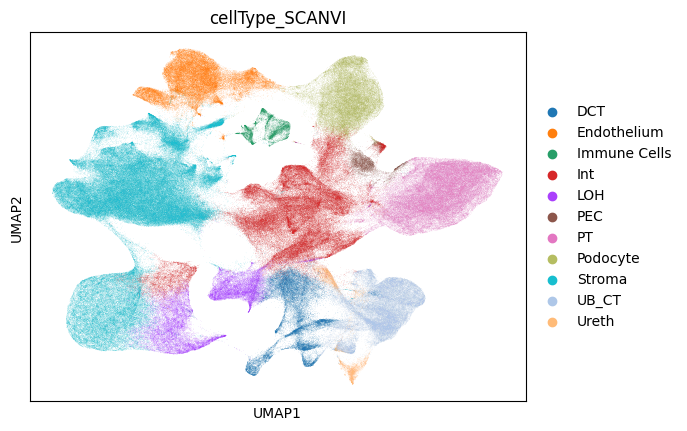

In [9]:
scanvi_model.train(max_epochs = 5, plan_kwargs={"lr":learning_rate}, early_stopping = earlyStopping, batch_size=batch_size)
latent = scanvi_model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=min_distUMAP)
sc.pl.umap(adata, color = "cellType_SCANVI")

INFO     Training for 5 epochs.                                                                                    


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Epoch 5/5:  80%|████████  | 4/5 [00:55<00:13, 13.75s/it, v_num=1, train_loss=139]

Epoch 5/5: 100%|██████████| 5/5 [01:08<00:00, 13.75s/it, v_num=1, train_loss=139]

Epoch 5/5: 100%|██████████| 5/5 [01:08<00:00, 13.75s/it, v_num=1, train_loss=140]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 5/5: 100%|██████████| 5/5 [01:08<00:00, 13.75s/it, v_num=1, train_loss=140]

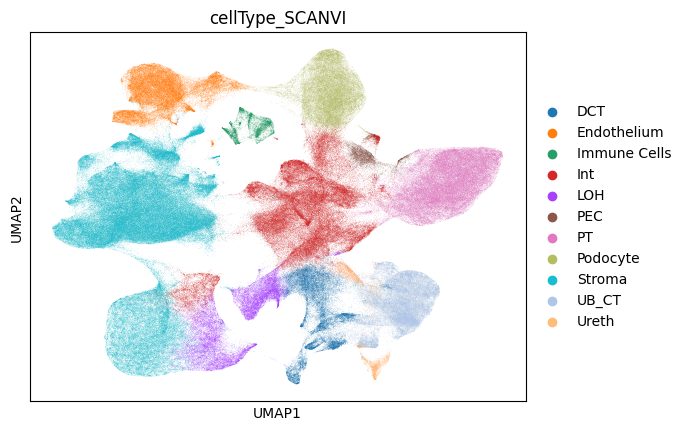

In [10]:
scanvi_model.train(max_epochs = 5, plan_kwargs={"lr":learning_rate}, early_stopping = earlyStopping, batch_size=batch_size)
latent = scanvi_model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=min_distUMAP)
sc.pl.umap(adata, color = "cellType_SCANVI")

INFO     Training for 5 epochs.                                                                                    


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Epoch 5/5:  80%|████████  | 4/5 [00:51<00:12, 12.84s/it, v_num=1, train_loss=137]

Epoch 5/5: 100%|██████████| 5/5 [01:04<00:00, 12.78s/it, v_num=1, train_loss=137]

Epoch 5/5: 100%|██████████| 5/5 [01:04<00:00, 12.78s/it, v_num=1, train_loss=138]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 5/5: 100%|██████████| 5/5 [01:04<00:00, 12.82s/it, v_num=1, train_loss=138]

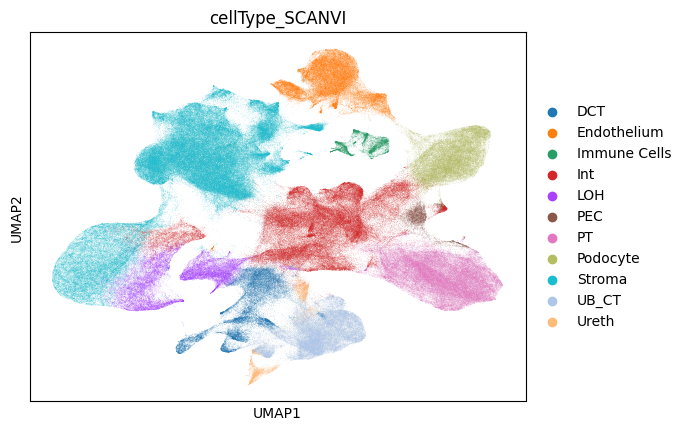

In [11]:
scanvi_model.train(max_epochs = 5, plan_kwargs={"lr":learning_rate}, early_stopping = earlyStopping, batch_size=batch_size)
latent = scanvi_model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=min_distUMAP)
sc.pl.umap(adata, color = "cellType_SCANVI")

INFO     Training for 5 epochs.                                                                                    


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Epoch 5/5:  80%|████████  | 4/5 [00:50<00:12, 12.69s/it, v_num=1, train_loss=137]

Epoch 5/5: 100%|██████████| 5/5 [01:03<00:00, 12.65s/it, v_num=1, train_loss=137]

Epoch 5/5: 100%|██████████| 5/5 [01:03<00:00, 12.65s/it, v_num=1, train_loss=138]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 5/5: 100%|██████████| 5/5 [01:03<00:00, 12.70s/it, v_num=1, train_loss=138]

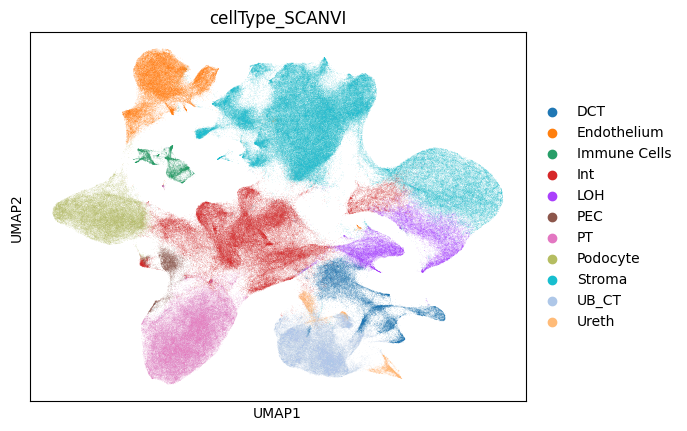

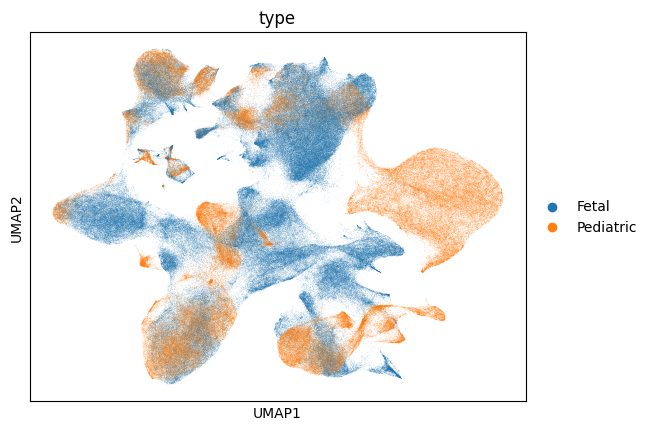

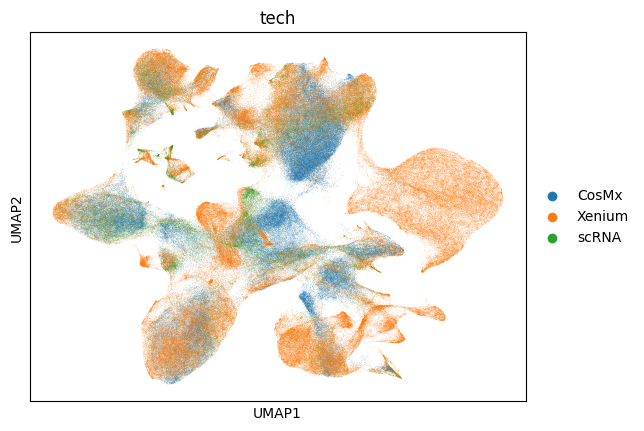

In [12]:
scanvi_model.train(max_epochs = 5, plan_kwargs={"lr":learning_rate}, early_stopping = earlyStopping, batch_size=batch_size)
latent = scanvi_model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=min_distUMAP)
sc.pl.umap(adata, color = "cellType_SCANVI")
sc.pl.umap(adata, color = "type")
sc.pl.umap(adata, color = "tech")

In [13]:
adata.write(output_file)